In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as pyplot
import scipy.stats 
import statsmodels.api as sm
from statsmodels.formula.api import ols

Lets first acquire the data.

In [2]:
boston_df=pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/boston_housing.csv')

Now we can become acquainted with the variables in the dataset.

In [5]:
boston_df.columns

Index(['Unnamed: 0', 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
       'RAD', 'TAX', 'PTRATIO', 'LSTAT', 'MEDV'],
      dtype='object')

Plotting the Median value of owner occupied homes with a boxplot.

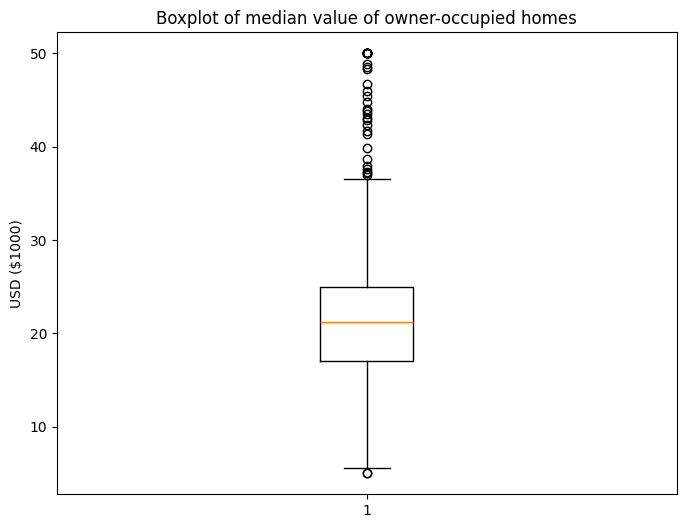

In [13]:
boston_medv_df = boston_df.MEDV
pyplot.figure(figsize=(8,6))
pyplot.boxplot(boston_medv_df)
pyplot.title('Boxplot of median value of owner-occupied homes')
pyplot.ylabel("USD ($1000)")
pyplot.show()

It appears that the median value is above $20,000. Now let's see if the number differs when the house is near the Charles River. 

Text(0, 0.5, 'USD ($1000)')

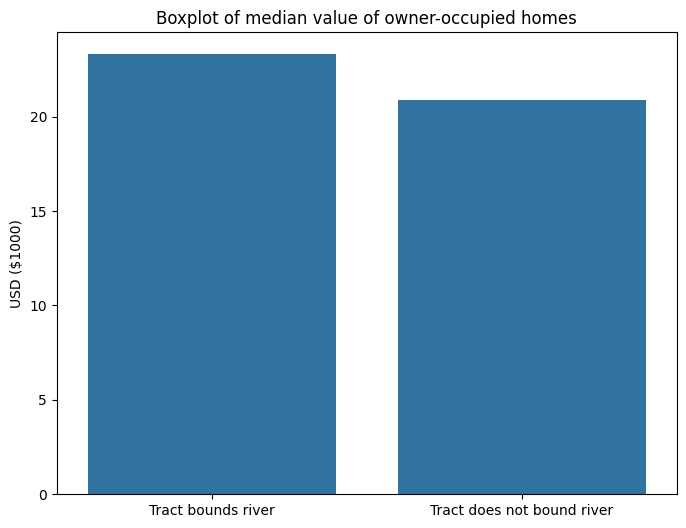

In [26]:
bosotn_nearcharles_df = boston_df[boston_df['CHAS'] == 1]
bosotn_notnearcharles_df = boston_df[boston_df['CHAS'] == 0]
bosotn_medv_nearcharles_median = np.median(bosotn_nearcharles_df.MEDV)
bosotn_medv_notnearcharles_median = np.median(bosotn_notnearcharles_df.MEDV)

pyplot.figure(figsize=(8,6))
sns.barplot(x=['Tract bounds river', 'Tract does not bound river'], y=(bosotn_medv_nearcharles_median, bosotn_medv_notnearcharles_median))
pyplot.title('Boxplot of median value of owner-occupied homes')
pyplot.ylabel('USD ($1000)')

It appears there is a difference in median house price. Now let's see if it is statistically significant.

Null hypothesis: Housing districts that bound the charles river has no effect on median value of owner-occupied homes.

Alternative hypothesis: Housing districts that bound the charles river differ from districts that do not bound the charles river in the median value of owner-occupied homes.

Alpha = 0.05. Let's begin with the levene test.

In [29]:
scipy.stats.levene(bosotn_nearcharles_df.MEDV, bosotn_notnearcharles_df.MEDV, center='mean')

LeveneResult(statistic=np.float64(8.75190489604598), pvalue=np.float64(0.003238119367639829))

Since the p-value is greater than 0.05 we can assume equality of variance.

In [32]:
scipy.stats.ttest_ind(bosotn_nearcharles_df.MEDV, bosotn_notnearcharles_df.MEDV, equal_var = True)

TtestResult(statistic=np.float64(3.996437466090509), pvalue=np.float64(7.390623170519905e-05), df=np.float64(504.0))

Since the p-value is less than our alpha value, we reject the null hypothesis as there is enough proof that there is a statistical difference in median home values based on whether the housing district bounds the river. 

Now let's determine if there is a difference in median value of houses pior to 1940. 

In [63]:
AGE_MEDV_boston_df = {
    '35 years or younger': boston_df.MEDV[boston_df['AGE'] < 36],
    '35 years to 70 years': boston_df.MEDV[(boston_df['AGE'] > 35) & (boston_df['AGE'] < 70)],
    '70 years or older': boston_df.MEDV[boston_df['AGE'] > 69]
}

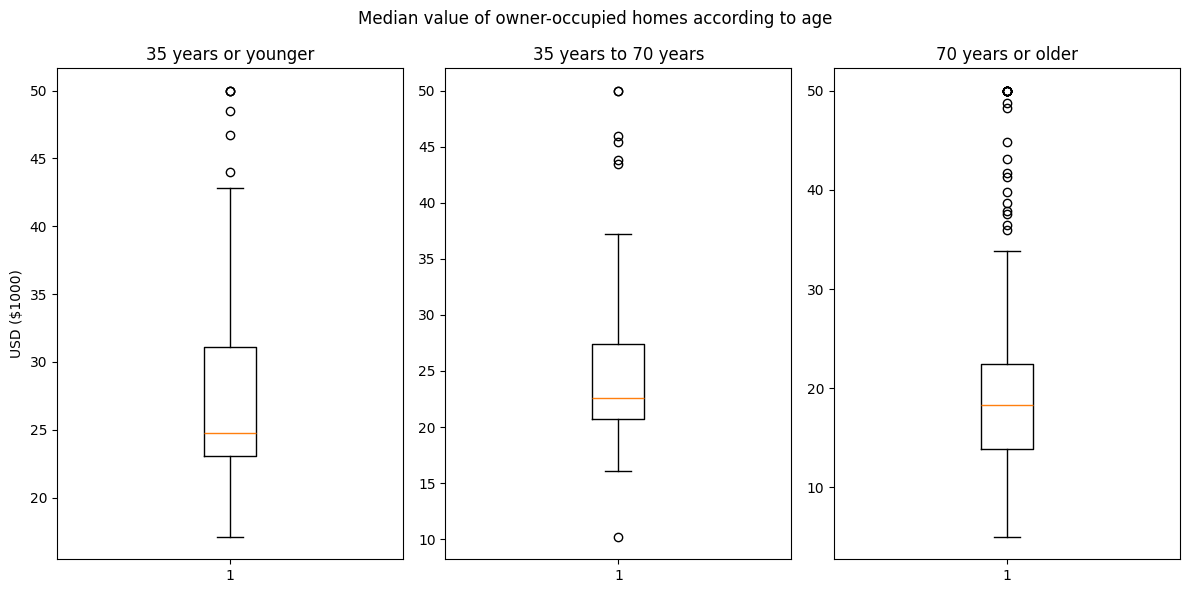

In [73]:
pyplot.figure(figsize=(12, 6))

pyplot.subplot(1, 3, 1)
pyplot.boxplot(AGE_MEDV_boston_df['35 years or younger'])
pyplot.title('35 years or younger')
pyplot.ylabel('USD ($1000)')

pyplot.subplot(1, 3, 2)
pyplot.boxplot(AGE_MEDV_boston_df['35 years to 70 years'])
pyplot.title('35 years to 70 years')

pyplot.subplot(1, 3, 3)
pyplot.boxplot(AGE_MEDV_boston_df['70 years or older'])
pyplot.title('70 years or older')

pyplot.suptitle('Median value of owner-occupied homes according to age')
pyplot.tight_layout()
pyplot.show()

It appears that the median value differs by less than $5,000. Let's determine if the values are statistically signfificant.

Let's state the hypothesis.

Null hypothesis: There is no difference in median value of owner-occupied homes according to age when grouped by 35 years or younger, 35 years to 70 years, and 70 years or older.

Alternative hypothesis: There is a difference in median value of owner-occupied homes according to age when grouped by 35 years or younger, 35 years to 70 years, and 70 years or older. 

Alpha = 0.05.

In [76]:
lm = ols('MEDV ~ AGE', data = boston_df).fit()
table = sm.stats.anova_lm(lm)
print(table)

             df        sum_sq      mean_sq          F        PR(>F)
AGE         1.0   6069.761065  6069.761065  83.477459  1.569982e-18
Residual  504.0  36646.534350    72.711378        NaN           NaN


Since the p-value associated with the f-statistic is less than the alpha value, we reject the null hypothesis as there is sufficient proof that the median value changes depending on the age of the house. 

Now let's determine whether there is a relationship between nitric oxide concentrations and proportion of non-retail business acres per town. 

Null hypothesis: There is no relationship between nitric oxide concentrations and proportion of non-retail business acres per town.

Alternative hypothesis: There is a relationship between nitric oxide concentrations and proportion of non-retail business acres per town.

Alpha value = 0.05. 

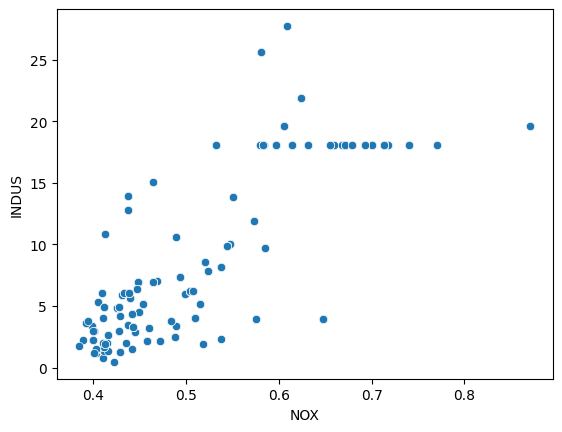

In [77]:
ax = sns.scatterplot(x='NOX', y='INDUS', data=boston_df)

There appears to be a postive correlation. As we increase in nitric oxide concentrations (NOX), there is an increase in proportion of non-retail business acres per town. Let's determine if the change is statistically significant. 

In [79]:
scipy.stats.pearsonr(boston_df['NOX'], boston_df['INDUS'])

PearsonRResult(statistic=np.float64(0.763651446920915), pvalue=np.float64(7.913361061241532e-98))

Since the p-value is less than our alpha value, we reject the null hypothesis as there is sufficient proof that a relationship exists between nitric oxide concentrations and proportion of non-retail business acres per town. 

Now, let's look at the impact of additional weighted distance to the five Boston emplyoment centres on the median value of owner occupied homes. 

Null hypothesis: there is no impact of additional weighted distance to the five Boston employment centres on the median value of owner occupied homes. 

Alternative hypthesis: there is a impact of additional weighted distance to the five Boston employment centres on the median value of owner occupied homes.

Alpha value: 0.05. 

In [80]:
lm = ols('MEDV ~ DIS', data = boston_df).fit()
table= sm.stats.anova_lm(lm)
print(table)

             df        sum_sq      mean_sq         F        PR(>F)
DIS         1.0   2668.246572  2668.246572  33.57957  1.206612e-08
Residual  504.0  40048.048843    79.460414       NaN           NaN


Since the p-value is less than the alpha value, we reject the null hypothesis as there is sufficient evidence that additional weighted distance to the five Boston employment centres influences the median value of owner occupied homes. 

Finally, let's create a histogram of the pupil to student ratio. 

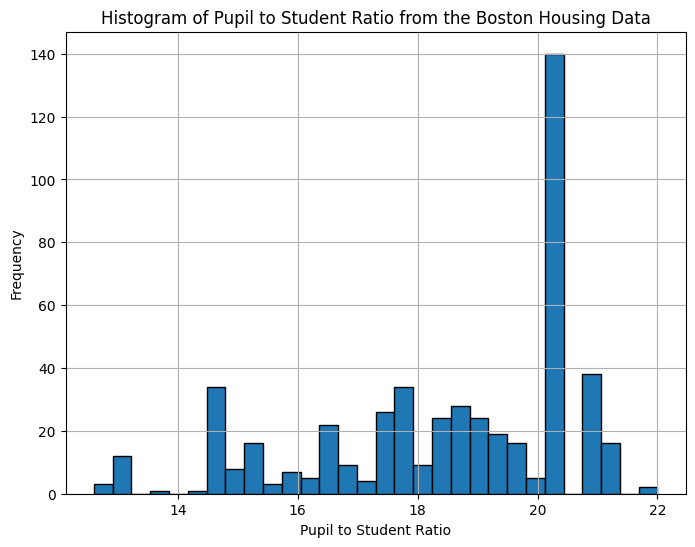

In [81]:
pyplot.figure(figsize=(8, 6))
pyplot.hist(boston_df['PTRATIO'], bins=30, edgecolor='black')  # Adjust bins for desired number
pyplot.title('Histogram of Pupil to Student Ratio from the Boston Housing Data')
pyplot.xlabel('Pupil to Student Ratio')
pyplot.ylabel('Frequency')
pyplot.grid(True)
pyplot.show()

It appears that most ratios are between 15 to 22. The highest number is after 20. 